# Problem 5: Rough-turbulent Flow above a Flat Plate
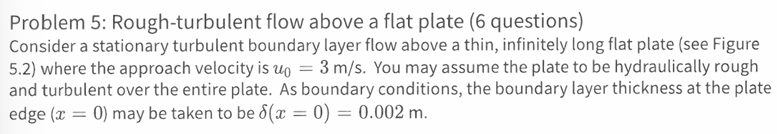
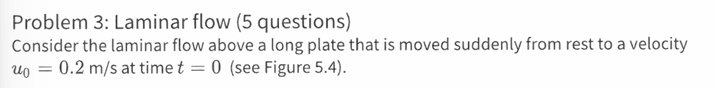

In [18]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.integrate import solve_ivp

In [19]:
u_0 = 3                   # Plate velocity amplitude [m/s]
delta_0 = 0.002             # Initial boundary layer thickness [m]
viscosity = 1.3*10**-6      # Kinematic viscosity [m2/s]
rho_water = 1000            # density of water (kg/m^3)
kappa = 0.4                 # von Karman constant

### Question 5.1
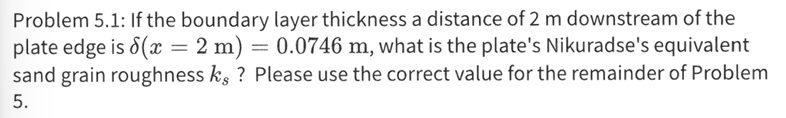
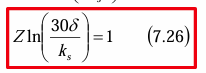 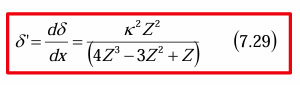
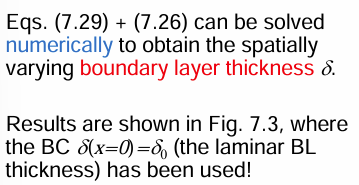

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

# ---------- Input / problem data ----------
kappa = 0.4             # von Karman constant (use course value)
k_s = 1.0e-3             # Nikuradse ks [m] (replace with your value)
delta0 = 0.002           # delta(x=0) [m] (given)
x0 = 0.0
x_end = 2.0              # integrate to x=2 m (or any x you need)
# ------------------------------------------

def Z_from_delta(delta, ks=k_s):
    """Eq. (7.26): Z = 1 / ln(30 * delta / ks), robustified."""
    arg = 30.0 * delta / ks
    # prevent ln(arg) <= 0 or too small: enforce safe lower bound
    if arg <= 1.0000001:
        # for very small arg, return a small positive Z (physical limit)
        return 1.0 / np.log(1.0000001)
    return 1.0 / np.log(arg)

def ddelta_dx(x, y):
    """Right-hand side of Eq. (7.29): dδ/dx = kappa^2 * Z^2 / (4 Z^3 - 3 Z^2 + Z)."""
    delta = float(y[0])
    Z = Z_from_delta(delta, ks=k_s)
    # denominator from eq. (7.29)
    denom = 4.0 * Z**3 - 3.0 * Z**2 + Z
    # guard against tiny denom
    if abs(denom) < 1e-12:
        return [0.0]
    ddel_dx = (kappa**2) * (Z**2) / denom
    return [ddel_dx]

# integrate
sol = solve_ivp(fun=ddelta_dx, t_span=(x0, x_end), y0=[delta0],
                rtol=1e-8, atol=1e-10, dense_output=True)

# outputs
x_vals = sol.t
delta_vals = sol.y[0]

print(f"Integrated from x={x0} to x={x_end}")
print(f"delta(0) = {delta0} m")
print(f"delta({x_end}) = {delta_vals[-1]} m")


Integrated from x=0.0 to x=2.0
delta(0) = 0.002 m
delta(2.0) = 0.07765682422344622 m


In [ ]:
# The same as above but here the k_s is unknown and we want to find it such that delta(x_end) = target_delta
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# ---------- Input / known data ----------
delta0 = 0.002             # delta(x=0) [m]
x0 = 0.0
x_end = 2.0                # x where delta is known
target_delta = 0.0746      # given delta(2.0)
# -----------------------------------------

def integrate_delta_for_ks(ks, x_end=x_end, delta0=delta0, kappa=kappa):
    """Integrate dδ/dx (Eq.7.29) using Z from Eq.7.26 for a given ks.
       Returns δ(x_end)."""
    def Z_from_delta(delta, ks_local):
        arg = 30.0 * delta / ks_local
        if arg <= 1.0000001:
            return 1.0 / np.log(1.0000001)
        return 1.0 / np.log(arg)

    def ddelta_dx(x, y):
        delta = float(y[0])
        Z = Z_from_delta(delta, ks)
        denom = 4.0 * Z**3 - 3.0 * Z**2 + Z
        if abs(denom) < 1e-14:
            return [0.0]
        ddel = (kappa**2) * (Z**2) / denom
        return [ddel]

    sol = solve_ivp(fun=ddelta_dx, t_span=(x0, x_end), y0=[delta0],
                    rtol=1e-8, atol=1e-10)
    if not sol.success:
        raise RuntimeError("ODE solver failed for ks={}".format(ks))
    return float(sol.y[0, -1])

def objective(ks):
    """Root function: delta(x_end; ks) - target_delta"""
    delt = integrate_delta_for_ks(ks)
    return delt - target_delta

# --- find bracket for root on log-scale ---
ks_min = 1e-8
ks_max = 1e-1
log_ks = np.logspace(np.log10(ks_min), np.log10(ks_max), 50)
Fvals = []
for kval in log_ks:
    try:
        Fvals.append(objective(kval))
    except Exception:
        Fvals.append(np.nan)

# locate sign change
bracket = None
for i in range(len(log_ks)-1):
    a, b = log_ks[i], log_ks[i+1]
    Fa, Fb = Fvals[i], Fvals[i+1]
    if np.isnan(Fa) or np.isnan(Fb):
        continue
    if Fa == 0:
        bracket = (a, a); break
    if Fa * Fb < 0:
        bracket = (a, b); break
# if none found, try widen/adjust
if bracket is None:
    # fallback: try simple bracket around where F is smallest in magnitude
    idx = np.nanargmin(np.abs(Fvals))
    small = log_ks[max(0, idx-1)]
    large = log_ks[min(len(log_ks)-1, idx+1)]
    bracket = (small, large)

# if bracket is a point, report
if bracket[0] == bracket[1]:
    ks_root = bracket[0]
else:
    # use brentq on the found bracket
    ks_root = brentq(objective, bracket[0], bracket[1], xtol=1e-12, rtol=1e-10, maxiter=100)

# verification
delta_found = integrate_delta_for_ks(ks_root)

print(f"delta(2.0) computed = {delta_found:.12f} m (target = {target_delta:.12f} m)")
print(f"Found k_s = {ks_root*1000:.0f} mm")

delta(2.0) computed = 0.074600000000 m (target = 0.074600000000 m)
Found k_s = 1 mm


### Question 5.2
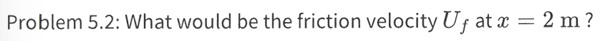
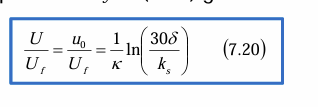

In [ ]:
# Adjusted manually (AFTER finding k_s)
delta_2 = 0.0746  # boundary layer thickness at x=2m [m]
k_s = 1.0e-3  # Nikuradse roughness length [m] (replace with your found value)

U_f = u_0/(1/kappa * np.log(30*delta_2/k_s))

print(f"Friction velocity U_f = {U_f:.2f} m/s")


Friction velocity U_f = 0.16 m/s


### Question 5.3
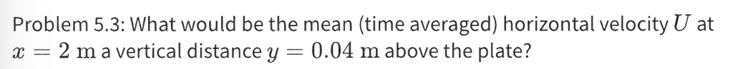
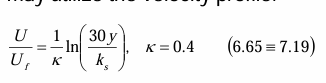

In [67]:
# Wall Shear Stress P10 eq. 6.65 = 7.19 p.7 (the same equation just using the U/U_f instead of u_0/U_f)
y2 = 0.04  # m

def velocity_profile(delta, y):
    if y < k_s/30.0:
        return 0             # near-bed matching
    elif y > delta:
        return u_0            # outside BL
    else:
        return U_f * (1 / kappa) * np.log(30*y2 / k_s)

print(f"Velocity at y={y2} m: {velocity_profile(delta_2, y2):.2f} m/s")

Velocity at y=0.04 m: 2.76 m/s


### Question 5.4
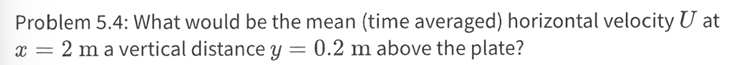
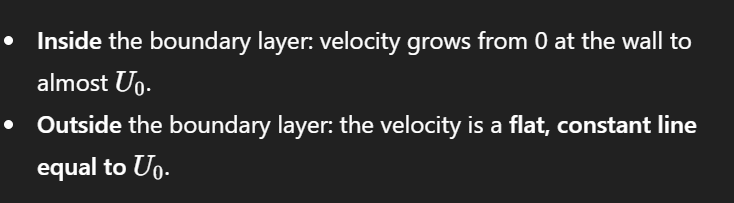

In [68]:
# Wall Shear Stress P10 eq. 6.65 = 7.19 p.7 (the same equation just using the U/U_f instead of u_0/U_f)
y2 = 0.2  # m

def velocity_profile(delta, y):
    if y < k_s/30.0:
        return 0             # near-bed matching
    elif y > delta:
        return u_0            # outside BL
    else:
        return U_f * (1 / kappa) * np.log(30*y2 / k_s)

print(f"Velocity at y={y2} m: {velocity_profile(delta_2, y2):.2f} m/s")

Velocity at y=0.2 m: 3.00 m/s


### Question 5.5
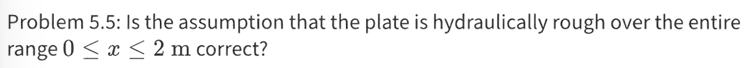
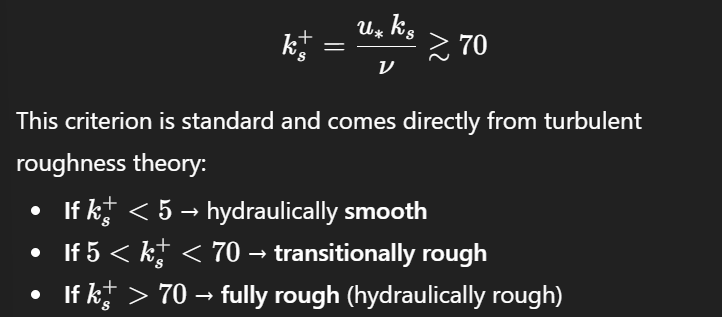

In [ ]:
# Yes

### Question 5.6
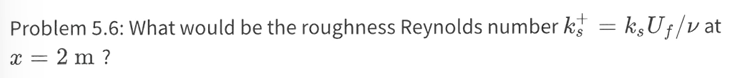

In [73]:
k_splus = k_s * U_f / viscosity

print(f"k_s+ = {k_splus:.0f}")

k_s+ = 123
